# Eksplorasi Awal Data Pasien Gagal Jantung untuk Analisis Risiko Rawat Ulang
Tahap ini bertujuan untuk memahami struktur dan isi dataset pasien gagal jantung dengan menampilkan beberapa baris awal data. Melalui proses ini, dapat diperoleh gambaran umum mengenai variabel yang tersedia, seperti karakteristik pasien dan faktor klinis yang berpotensi memengaruhi kejadian rawat ulang. Eksplorasi awal ini menjadi langkah penting sebelum dilakukan analisis lanjutan atau pemodelan.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("heart_failure_readmission_dataset.csv")

df.head()

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               3000 non-null   int64  
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   object 
 3   bmi                      2910 non-null   float64
 4   bnp                      3000 non-null   int64  
 5   sodium                   2910 non-null   float64
 6   creatinine               2910 non-null   float64
 7   systolic_bp              3000 non-null   int64  
 8   heart_rate               3000 non-null   int64  
 9   ace_inhibitor            3000 non-null   int64  
 10  beta_blocker             3000 non-null   int64  
 11  diuretic                 3000 non-null   int64  
 12  adherence_score          3000 non-null   float64
 13  income_level             3000 non-null   object 
 14  distance_to_hospital_km 

Data ini berisi 3000 pasien dengan total 16 informasi berbeda tentang tiap pasien. Jadi bisa dibayangkan seperti tabel besar yang menyimpan data kondisi kesehatan dan latar belakang pasien gagal jantung.

Sebagian besar datanya sudah lengkap, tapi ada beberapa bagian seperti BMI, kadar sodium, dan creatinine yang masih ada data kosong (sekitar 90 data yang belum terisi). Ini hal yang wajar, tapi nanti biasanya perlu dibereskan dulu sebelum analisis lebih lanjut.

Isi datanya cukup lengkap, mulai dari umur, jenis kelamin, kondisi tubuh, hasil pemeriksaan medis, tekanan darah, detak jantung, obat yang dikonsumsi, sampai ke kondisi sosial seperti tingkat pendapatan dan jarak ke rumah sakit. Nah, tujuan utama dari data ini adalah untuk melihat apakah pasien tersebut dirawat kembali dalam 30 hari atau tidak, yang ditandai di kolom terakhir.

Intinya, data ini sudah bagus dan siap dipakai, cuma perlu sedikit pembersihan dulu di bagian yang masih kosong supaya hasil analisisnya nanti lebih akurat.

In [ ]:
df.describe()

,patient_id,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d
count,3000.000000,3000.000000,2910.000000,3000.000000,2910.000000,2910.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,11499.500000,65.254333,28.109038,406.308000,138.089210,1.195082,129.588667,79.364000,0.521667,0.503333,0.489000,0.699377,25.399533,0.411333
std,866.169729,14.806465,4.949035,232.273101,4.031886,0.490563,20.257120,15.269465,0.499614,0.500072,0.499962,0.172973,14.145746,0.492157
min,10000.000000,40.000000,8.800000,50.000000,124.700000,-0.590000,61.000000,19.000000,0.000000,0.000000,0.000000,0.400000,1.000000,0.000000
25%,10749.750000,52.000000,24.800000,225.000000,135.300000,0.870000,116.000000,69.000000,0.000000,0.000000,0.000000,0.550000,12.800000,0.000000
50%,11499.500000,65.000000,28.100000,392.000000,138.100000,1.200000,130.000000,79.000000,1.000000,1.000000,0.000000,0.700000,25.450000,0.000000
75%,12249.250000,78.000000,31.500000,569.000000,140.800000,1.520000,143.000000,90.000000,1.000000,1.000000,1.000000,0.850000,37.525000,1.000000
max,12999.000000,90.000000,44.900000,1381.000000,151.600000,2.940000,196.000000,147.000000,1.000000,1.000000,1.000000,1.000000,50.000000,1.000000


Tabel ini menunjukkan ringkasan statistik dari data pasien secara keseluruhan.

Secara sederhana, kita bisa lihat bahwa rata-rata pasien berusia sekitar 65 tahun, dengan BMI sekitar 28 (cenderung sedikit di atas normal). Tekanan darah sistolik rata-rata di angka 129, dan detak jantung sekitar 79 bpm, yang masih dalam kisaran umum.

Untuk kondisi medis, nilai BNP rata-rata cukup tinggi (406) yang biasanya berkaitan dengan kondisi gagal jantung. Sementara itu, kreatinin rata-rata 1.19 menunjukkan fungsi ginjal yang perlu diperhatikan pada sebagian pasien.

Dari sisi pengobatan, sekitar 50% pasien menggunakan obat seperti ACE inhibitor, beta blocker, dan diuretik. Tingkat kepatuhan pasien terhadap pengobatan (adherence score) cukup baik, dengan rata-rata sekitar 0.7.

Yang menarik, sekitar 41% pasien mengalami rawat ulang dalam 30 hari, yang berarti cukup banyak pasien yang harus kembali ke rumah sakit. Ini jadi poin penting untuk analisis lebih lanjut, untuk mencari faktor apa saja yang memengaruhinya.

# Melihat Sebaran Pasien yang Dirawat Ulang dalam 30 Hari
Kode ini digunakan untuk menampilkan jumlah pasien yang dirawat ulang dalam 30 hari dan yang tidak dirawat ulang dalam bentuk grafik batang. Tujuannya adalah untuk melihat bagaimana distribusi data pada variabel utama (readmitted_30d), apakah jumlahnya seimbang atau tidak. Dari grafik ini, kita bisa langsung memahami apakah kasus rawat ulang lebih banyak terjadi atau justru lebih sedikit, sehingga bisa jadi gambaran awal sebelum melakukan analisis yang lebih dalam.

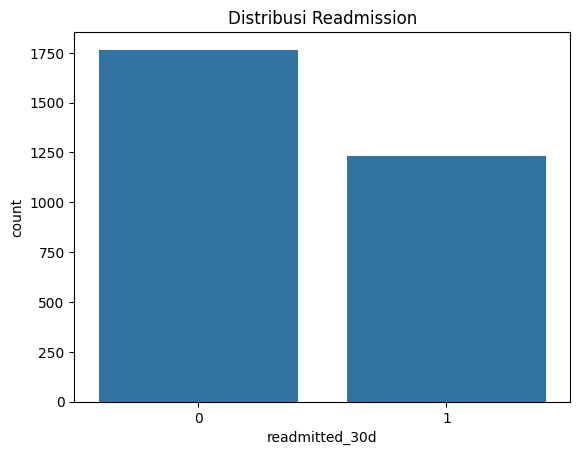

In [ ]:
sns.countplot(x='readmitted_30d', data=df)
plt.title("Distribusi Readmission")
plt.show()

Grafik tersebut menunjukkan distribusi pasien berdasarkan status readmission dalam 30 hari (readmitted_30d). Terlihat bahwa jumlah pasien yang tidak mengalami readmisi (0) lebih banyak dibandingkan dengan pasien yang mengalami readmisi (1). Secara visual, batang untuk kategori 0 lebih tinggi, yang mengindikasikan bahwa sebagian besar pasien tidak kembali dirawat dalam waktu 30 hari setelah keluar dari rumah sakit. Sementara itu, jumlah pasien yang mengalami readmisi masih cukup signifikan, meskipun lebih rendah. Hal ini menunjukkan bahwa meskipun mayoritas pasien tidak membutuhkan perawatan ulang dalam waktu dekat, tetap ada proporsi yang perlu diperhatikan karena berpotensi mencerminkan kualitas perawatan, kondisi kesehatan pasien, atau faktor lain seperti kepatuhan terhadap pengobatan dan tindak lanjut medis.

# Melihat Sebaran Data Setiap Variabel
Kode ini digunakan untuk menampilkan histogram dari setiap variabel numerik dalam dataset. Tujuannya adalah untuk melihat bagaimana penyebaran nilai pada masing-masing variabel, misalnya apakah datanya cenderung normal, miring, atau memiliki nilai yang ekstrem. Dengan grafik ini, kita bisa lebih mudah memahami pola data secara keseluruhan dan mendeteksi hal-hal penting seperti outlier atau ketidakseimbangan data sebelum lanjut ke analisis berikutnya.

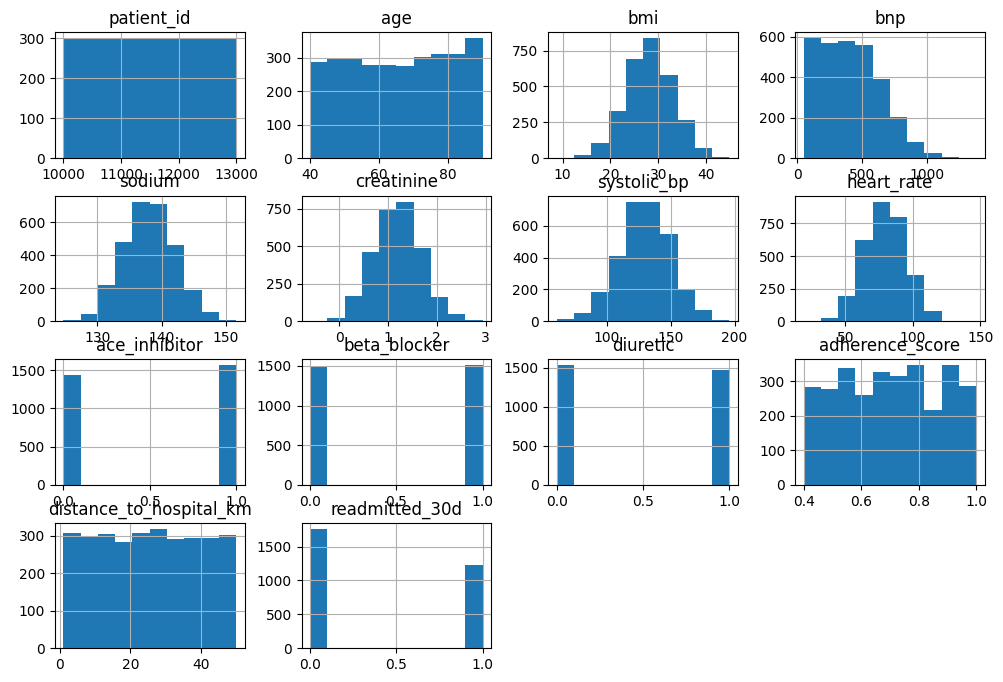

In [ ]:
df.hist(figsize=(12,8))
plt.show()

pada histogram distribusi data, terlihat bahwa beberapa variabel seperti usia dan BMI memiliki sebaran yang cukup normal, sedangkan variabel seperti BNP cenderung tidak simetris (skewed). Selain itu, distribusi pada variabel target readmitted_30d menunjukkan bahwa jumlah pasien yang tidak dirawat ulang lebih banyak dibandingkan yang dirawat ulang, sehingga data cenderung tidak seimbang. Secara keseluruhan, visualisasi ini menunjukkan bahwa data cukup baik untuk analisis, namun terdapat beberapa karakteristik seperti ketidakseimbangan data dan distribusi yang tidak merata yang perlu diperhatikan dalam proses pemodelan.

# Melihat Hubungan Antar Variabel dalam Data
Kode ini digunakan untuk menampilkan heatmap korelasi, yaitu gambaran hubungan antar variabel numerik dalam dataset. Dari grafik ini, kita bisa melihat apakah suatu variabel memiliki hubungan yang kuat, lemah, positif, atau negatif dengan variabel lain. Warna yang lebih terang atau gelap menunjukkan seberapa kuat hubungan tersebut. Tujuannya adalah untuk membantu memahami keterkaitan antar faktor, serta mengidentifikasi variabel mana yang paling berpengaruh, terutama terhadap kemungkinan pasien dirawat ulang.

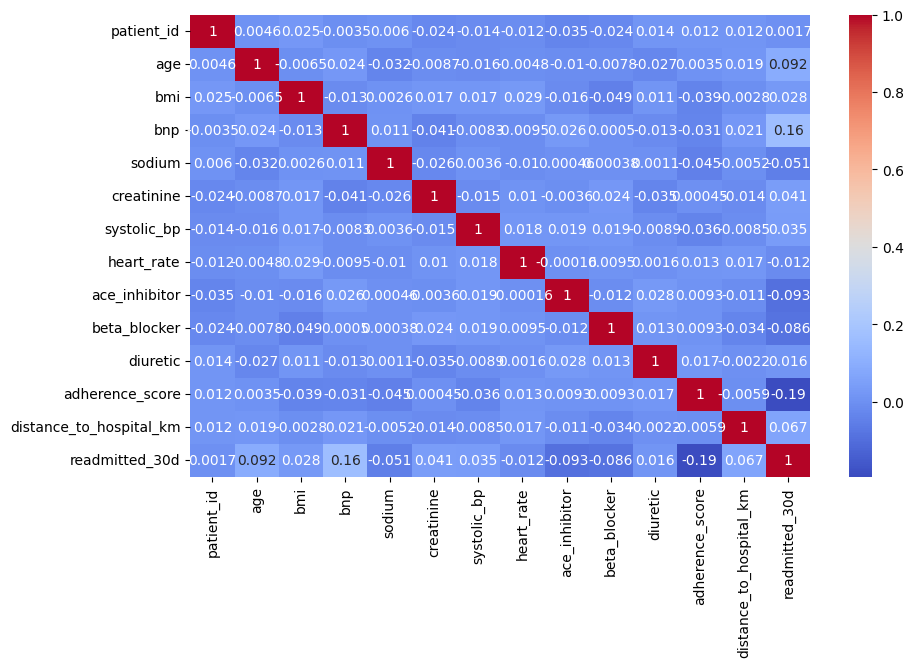

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Heatmap korelasi, terlihat bahwa sebagian besar variabel memiliki hubungan yang lemah satu sama lain, ditandai dengan nilai korelasi yang mendekati nol. Namun, terdapat beberapa hubungan yang cukup menarik, seperti adherence_score yang memiliki korelasi negatif terhadap readmitted_30d, yang berarti semakin tinggi kepatuhan pasien maka kemungkinan dirawat ulang semakin rendah. Selain itu, bnp menunjukkan hubungan positif meskipun tidak terlalu kuat, yang mengindikasikan bahwa nilai BNP yang lebih tinggi cenderung meningkatkan risiko readmisi.

# Mengecek Missing Value
Kode ini digunakan untuk menghitung jumlah data yang kosong di setiap kolom dalam dataset. Tujuannya adalah untuk mengetahui bagian mana dari data yang belum lengkap, sehingga bisa diputuskan apakah data tersebut perlu diisi, dihapus, atau ditangani dengan cara tertentu. Ini penting dilakukan di awal analisis supaya hasil yang diperoleh nantinya tetap akurat dan tidak bias karena adanya data yang hilang.

In [ ]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
bmi,90
bnp,0
sodium,90
creatinine,90
systolic_bp,0
heart_rate,0
ace_inhibitor,0


Hasil ini menunjukkan bahwa sebagian besar data sudah lengkap, tetapi ada beberapa kolom yang masih memiliki nilai kosong. Tepatnya, pada variabel bmi, sodium, dan creatinine masing-masing terdapat 90 data yang hilang, sementara kolom lainnya tidak memiliki data kosong sama sekali. Artinya, hanya beberapa bagian kecil dari data yang perlu diperhatikan dan dibersihkan. Secara keseluruhan, kondisi dataset sudah cukup baik, namun tetap perlu penanganan pada data yang hilang agar analisis selanjutnya bisa lebih akurat.

# Mengisi Data yang Kosong dengan Nilai Tengah (Median)
Langkah ini dilakukan untuk mengatasi data yang kosong (missing values) pada beberapa kolom, yaitu bmi, sodium, dan creatinine. Caranya adalah dengan mengisi nilai yang kosong menggunakan nilai median (nilai tengah) dari masing-masing kolom tersebut.

Penggunaan median dipilih karena lebih aman dan tidak terlalu terpengaruh oleh nilai ekstrem (outlier). Dengan cara ini, data yang sebelumnya kosong menjadi terisi, sehingga dataset menjadi lebih lengkap dan siap digunakan untuk analisis atau pemodelan tanpa terganggu oleh missing values.

In [ ]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)
df['sodium'].fillna(df['sodium'].median(), inplace=True)
df['creatinine'].fillna(df['creatinine'].median(), inplace=True)

/tmp/ipykernel_4046/2715418286.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)
/tmp/ipykernel_4046/2715418286.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

# Mengatasi Nilai Ekstrem (Outlier) pada Data
Kode ini digunakan untuk membatasi nilai yang terlalu ekstrem (outlier) pada beberapa variabel, yaitu bmi, age, sodium, dan creatinine. Caranya adalah dengan “memotong” nilai yang berada di luar batas wajar, yaitu di bawah persentil 1% dan di atas persentil 99%.

Jadi, kalau ada nilai yang terlalu kecil atau terlalu besar, nilainya akan disesuaikan ke batas tersebut, bukan dihapus. Tujuannya supaya data menjadi lebih stabil dan tidak terlalu dipengaruhi oleh nilai-nilai ekstrem yang bisa mengganggu hasil analisis atau model nantinya.

In [ ]:
for col in ['bmi','age','sodium','creatinine']:
    df[col] = df[col].clip(
        lower=df[col].quantile(0.01),
        upper=df[col].quantile(0.99)
    )

# Menghapus Kolom yang Tidak Diperlukan

In [ ]:
df.drop(['patient_id'], axis=1, inplace=True)

In [ ]:
df.head()

,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d,gender_Male,income_level_Low,income_level_Medium,bmi_age_ratio,sodium_creatinine_ratio
0,76,23.9,738,135.3,1.58,151,93,1,1,0,0.98,12.4,0,True,False,True,0.310390,52.441860
1,77,32.3,405,143.0,1.50,107,74,1,0,1,0.66,38.8,1,True,False,True,0.414103,57.200000
2,42,29.3,399,138.1,1.43,121,97,1,0,1,0.93,43.5,1,True,True,False,0.681395,56.831276
3,83,29.1,524,135.1,0.91,114,66,0,1,1,0.54,33.3,1,False,True,False,0.346429,70.732984
4,48,24.2,301,139.5,0.54,122,79,1,1,1,0.78,21.3,0,False,False,False,0.493878,90.584416


Pada tahap ini, terjadi beberapa perubahan pada dataset setelah proses preprocessing dilakukan. Kolom yang dihapus adalah patient_id karena hanya berfungsi sebagai identitas pasien dan tidak memiliki pengaruh dalam analisis. Selain itu, terdapat penambahan beberapa kolom baru, seperti gender_Male, income_level_Low, dan income_level_Medium yang merupakan hasil dari proses perubahan data kategorik menjadi numerik. Tidak hanya itu, ditambahkan juga fitur baru seperti bmi_age_ratio dan sodium_creatinine_ratio yang merupakan hasil perhitungan untuk memperkaya informasi dalam data. Dengan perubahan ini, dataset menjadi lebih siap digunakan untuk analisis lanjutan karena seluruh variabel sudah berbentuk numerik dan lebih informatif.

# Mengubah Data Kategorik Menjadi Numerik

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.head()

,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d,gender_Male,income_level_Low,income_level_Medium
0,76,23.9,738,135.3,1.58,151,93,1,1,0,0.98,12.4,0,True,False,True
1,77,32.3,405,143.0,1.50,107,74,1,0,1,0.66,38.8,1,True,False,True
2,42,29.3,399,138.1,1.43,121,97,1,0,1,0.93,43.5,1,True,True,False
3,83,29.1,524,135.1,0.91,114,66,0,1,1,0.54,33.3,1,False,True,False
4,48,24.2,301,139.5,0.54,122,79,1,1,1,0.78,21.3,0,False,False,False


# Menambahkan Fitur Baru dari Perhitungan Data (Feature Engineering)
Kode ini digunakan untuk membuat variabel baru dari hasil perhitungan variabel yang sudah ada. Pertama, dibuat bmi_age_ratio, yaitu perbandingan antara BMI dan usia, untuk melihat kondisi tubuh pasien relatif terhadap umurnya. Kedua, dibuat sodium_creatinine_ratio, yaitu perbandingan antara kadar sodium dan creatinine, yang bisa memberi gambaran tambahan terkait kondisi kesehatan pasien.

Penambahan angka +1 pada pembagi bertujuan untuk menghindari pembagian dengan nol. Dengan adanya fitur baru ini, informasi dalam dataset menjadi lebih kaya dan diharapkan bisa membantu meningkatkan hasil analisis atau model yang akan dibuat.

In [ ]:
df['bmi_age_ratio'] = df['bmi'] / (df['age'] + 1)
df['sodium_creatinine_ratio'] = df['sodium'] / (df['creatinine'] + 1)

In [ ]:
df.head()

,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d,gender_Male,income_level_Low,income_level_Medium,bmi_age_ratio,sodium_creatinine_ratio
0,76,23.9,738,135.3,1.58,151,93,1,1,0,0.98,12.4,0,True,False,True,0.310390,52.441860
1,77,32.3,405,143.0,1.50,107,74,1,0,1,0.66,38.8,1,True,False,True,0.414103,57.200000
2,42,29.3,399,138.1,1.43,121,97,1,0,1,0.93,43.5,1,True,True,False,0.681395,56.831276
3,83,29.1,524,135.1,0.91,114,66,0,1,1,0.54,33.3,1,False,True,False,0.346429,70.732984
4,48,24.2,301,139.5,0.54,122,79,1,1,1,0.78,21.3,0,False,False,False,0.493878,90.584416


# Membagi Data Menjadi Data Latih dan Data Uji
Kode ini digunakan untuk membagi dataset menjadi dua bagian, yaitu data latih (training data) dan data uji (testing data). Variabel X berisi semua faktor atau fitur yang digunakan untuk prediksi, sedangkan y berisi target yang ingin diprediksi, yaitu apakah pasien dirawat ulang dalam 30 hari.

Data kemudian dibagi dengan komposisi 80% untuk latihan model dan 20% untuk pengujian. Tujuannya agar model bisa belajar dari sebagian data, lalu diuji pada data yang belum pernah dilihat sebelumnya untuk mengecek seberapa baik kinerjanya. Penggunaan random_state=42 memastikan hasil pembagian data tetap konsisten setiap kali kode dijalankan.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('readmitted_30d', axis=1)
y = df['readmitted_30d']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Menormalkan Skala Data agar Lebih Seimbang
Kode ini digunakan untuk menyamakan skala semua variabel agar memiliki rentang yang sebanding. Dengan bantuan StandardScaler, data diubah sehingga memiliki rata-rata mendekati 0 dan standar deviasi 1.
Proses ini dilakukan dengan cara melatih scaler pada data training (X_train), lalu hasilnya digunakan untuk mengubah data training dan data testing. Hal ini penting supaya model tidak “bingung” karena perbedaan skala antar variabel, misalnya antara usia, tekanan darah, dan jarak yang nilainya bisa sangat jauh berbeda. Dengan data yang sudah dinormalisasi, model biasanya bisa bekerja lebih optimal dan stabil.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Membangun Model Prediksi dengan Random Forest
Kode ini digunakan untuk membuat dan melatih model machine learning menggunakan metode Random Forest. Model ini bekerja dengan menggabungkan banyak pohon keputusan untuk menghasilkan prediksi yang lebih akurat dan stabil.

Pertama, model dibuat lalu dilatih menggunakan data training (X_train dan y_train). Setelah itu, model digunakan untuk memprediksi data testing (X_test), sehingga menghasilkan rf_pred, yaitu hasil prediksi apakah pasien akan dirawat ulang dalam 30 hari atau tidak. Tujuan dari langkah ini adalah untuk melihat kemampuan model dalam memprediksi berdasarkan data yang sudah dipelajari sebelumnya.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Membangun Model Prediksi dengan Gradient Boosting
Kode ini digunakan untuk membuat dan melatih model Gradient Boosting, yaitu metode machine learning yang membangun model secara bertahap dengan cara memperbaiki kesalahan dari model sebelumnya. Berbeda dengan Random Forest yang bekerja secara paralel, metode ini fokus pada peningkatan akurasi sedikit demi sedikit di setiap tahap.

Model dilatih menggunakan data training (X_train dan y_train), lalu digunakan untuk memprediksi data testing (X_test). Hasil prediksi tersebut disimpan dalam gb_pred, yang menunjukkan apakah pasien diperkirakan akan dirawat ulang dalam 30 hari atau tidak. Tujuan utamanya adalah untuk mendapatkan model dengan performa yang lebih baik melalui proses pembelajaran yang bertahap dan terarah.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# Membangun Model Prediksi dengan Neural Network
Kode ini digunakan untuk membuat dan melatih model Neural Network menggunakan MLPClassifier. Model ini bekerja dengan meniru cara kerja jaringan saraf manusia, yaitu dengan mempelajari pola dari data melalui beberapa lapisan (layer) yang saling terhubung.

Model dilatih menggunakan data training (X_train dan y_train) dengan batas maksimum iterasi sebanyak 500 agar proses pembelajaran bisa berjalan optimal. Setelah itu, model digunakan untuk memprediksi data testing (X_test), dan hasilnya disimpan dalam nn_pred. Tujuannya adalah untuk melihat seberapa baik model dalam mengenali pola dan memprediksi apakah pasien akan dirawat ulang dalam 30 hari atau tidak.

In [ ]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(max_iter=500)
nn.fit(X_train, y_train)
nn_pred = nn.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# Mencari Parameter Terbaik untuk Model Random Forest
Kode ini digunakan untuk mencari kombinasi parameter terbaik pada model Random Forest agar hasil prediksinya bisa lebih optimal. Proses ini dilakukan menggunakan GridSearchCV, yaitu metode yang mencoba berbagai kombinasi parameter secara otomatis.
Parameter yang diuji di sini adalah jumlah pohon (n_estimators) dan kedalaman pohon (max_depth). Setiap kombinasi akan diuji menggunakan cross-validation (cv=5), yaitu data dibagi menjadi beberapa bagian untuk memastikan model tidak hanya bagus di satu kondisi saja.
Setelah proses ini selesai, akan diperoleh model terbaik yang disimpan dalam rf_best. Model ini adalah versi Random Forest yang sudah dioptimalkan dan siap digunakan untuk prediksi dengan performa yang lebih baik.

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_param = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

rf_grid = GridSearchCV(RandomForestClassifier(), rf_param, cv=5)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_

# Mencari Parameter Terbaik untuk Model Gradient Boosting
Kode ini digunakan untuk menentukan kombinasi parameter terbaik pada model Gradient Boosting agar performanya lebih optimal. Dengan menggunakan GridSearchCV, model akan mencoba beberapa kombinasi nilai, seperti jumlah iterasi (n_estimators) dan kecepatan belajar (learning_rate).
Setiap kombinasi diuji menggunakan cross-validation sebanyak 5 kali (cv=5), sehingga hasilnya lebih stabil dan tidak bergantung pada satu pembagian data saja. Setelah semua percobaan selesai, akan dipilih model dengan performa terbaik yang disimpan dalam gb_best. Model ini diharapkan mampu memberikan prediksi yang lebih akurat dibandingkan pengaturan awal.

In [ ]:
gb_param = {
    'n_estimators':[100,150],
    'learning_rate':[0.01,0.1]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(), gb_param, cv=5)
gb_grid.fit(X_train, y_train)

gb_best = gb_grid.best_estimator_

# Mencari Struktur Terbaik untuk Model Neural Network
Kode ini digunakan untuk menentukan struktur terbaik pada Neural Network, khususnya pada bagian jumlah dan ukuran neuron di setiap layer (hidden_layer_sizes). Dengan bantuan GridSearchCV, model akan mencoba beberapa kombinasi arsitektur, seperti satu layer dengan 50 neuron atau dua layer dengan 64 dan 32 neuron.

Setiap kombinasi diuji menggunakan cross-validation sebanyak 3 kali (cv=3) untuk memastikan hasilnya cukup stabil. Setelah proses selesai, akan dipilih model terbaik yang disimpan dalam nn_best. Model ini merupakan versi Neural Network yang sudah dioptimalkan strukturnya agar dapat memberikan prediksi yang lebih baik.

In [ ]:
nn_param = {
    'hidden_layer_sizes':[(50,), (64,32)]
}

nn_grid = GridSearchCV(MLPClassifier(max_iter=500), nn_param, cv=3)
nn_grid.fit(X_train, y_train)

nn_best = nn_grid.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

# Menggabungkan Beberapa Model untuk Prediksi yang Lebih Kuat
Kode ini digunakan untuk menggabungkan beberapa model terbaik yang sudah dibuat sebelumnya, yaitu Random Forest, Gradient Boosting, dan Neural Network, ke dalam satu model yang disebut Voting Classifier. Tujuannya adalah agar hasil prediksi menjadi lebih kuat dan stabil dengan memanfaatkan kelebihan dari masing-masing model.

Metode yang digunakan adalah hard voting, yaitu setiap model memberikan prediksi, lalu hasil akhirnya ditentukan berdasarkan suara terbanyak. Setelah model gabungan ini dilatih menggunakan data training (X_train dan y_train), model akan digunakan untuk memprediksi data testing (X_test), dan hasilnya disimpan dalam ens_pred. Dengan pendekatan ini, diharapkan akurasi prediksi bisa lebih baik dibandingkan menggunakan satu model saja.

In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[('rf',rf_best), ('gb',gb_best), ('nn',nn_best)],
    voting='hard'
)

ensemble.fit(X_train, y_train)
ens_pred = ensemble.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# Mengevaluasi Kinerja Model Prediksi
Kode ini digunakan untuk mengevaluasi seberapa baik kinerja setiap model dalam memprediksi data testing. Model yang dibandingkan adalah Random Forest (RF), Gradient Boosting (GB), Neural Network (NN), dan model gabungan (Ensemble).

Hasil yang ditampilkan berupa classification report, yang berisi metrik penting seperti precision, recall, f1-score, dan accuracy. Dari sini, kita bisa melihat model mana yang paling baik dalam membedakan pasien yang dirawat ulang dan yang tidak. Dengan perbandingan ini, kita bisa menentukan model mana yang paling optimal untuk digunakan dalam analisis atau prediksi selanjutnya.

In [ ]:
from sklearn.metrics import classification_report

print("RF\n", classification_report(y_test, rf_best.predict(X_test)))
print("GB\n", classification_report(y_test, gb_best.predict(X_test)))
print("NN\n", classification_report(y_test, nn_best.predict(X_test)))
print("ENS\n", classification_report(y_test, ens_pred))

RF
               precision    recall  f1-score   support

           0       0.69      0.82      0.75       374
           1       0.57      0.39      0.46       226

    accuracy                           0.66       600
   macro avg       0.63      0.61      0.61       600
weighted avg       0.65      0.66      0.64       600

GB
               precision    recall  f1-score   support

           0       0.69      0.83      0.76       374
           1       0.58      0.39      0.47       226

    accuracy                           0.67       600
   macro avg       0.64      0.61      0.61       600
weighted avg       0.65      0.67      0.65       600

NN
               precision    recall  f1-score   support

           0       0.69      0.71      0.70       374
           1       0.50      0.48      0.49       226

    accuracy                           0.62       600
   macro avg       0.60      0.59      0.59       600
weighted avg       0.62      0.62      0.62       600

ENS
   

Berdasarkan hasil evaluasi, terlihat bahwa model Gradient Boosting (GB) memiliki performa paling baik secara keseluruhan dengan akurasi sekitar 67%, sedikit lebih tinggi dibanding Random Forest (66%), Ensemble (65%), dan Neural Network (62%).

Jika dilihat lebih dalam, semua model cenderung lebih baik dalam memprediksi pasien yang tidak dirawat ulang (kelas 0) dibandingkan yang dirawat ulang (kelas 1). Hal ini terlihat dari nilai recall kelas 0 yang cukup tinggi (sekitar 0.82–0.83), sementara recall untuk kelas 1 masih rendah (sekitar 0.38–0.48). Artinya, model masih cukup sering gagal mendeteksi pasien yang benar-benar akan dirawat ulang.

Model Neural Network memiliki performa paling rendah, meskipun sedikit lebih seimbang dalam mengenali kedua kelas. Sementara itu, model Ensemble yang menggabungkan beberapa model ternyata belum mampu melampaui performa Gradient Boosting.

Secara keseluruhan, Gradient Boosting menjadi pilihan terbaik, namun semua model masih perlu ditingkatkan, terutama dalam mendeteksi pasien yang berisiko dirawat ulang agar hasilnya lebih optimal dan bermanfaat dalam konteks medis.

# Mengukur Kemampuan Model dengan Kurva ROC dan Nilai AUC
Kode ini digunakan untuk melihat seberapa baik model dalam membedakan antara pasien yang dirawat ulang dan yang tidak, tanpa bergantung pada satu batas keputusan saja. Pertama, diambil nilai probabilitas prediksi dari masing-masing model (Random Forest, Gradient Boosting, dan Neural Network). Lalu dihitung ROC curve, yaitu hubungan antara tingkat false positive dan true positive. Dari kurva ini kemudian dihitung nilai AUC (Area Under Curve).
Nilai AUC ini penting karena menunjukkan kualitas model secara keseluruhan. Semakin mendekati 1, berarti model semakin baik dalam membedakan kedua kelas. Sebaliknya, jika mendekati 0.5, artinya model tidak jauh lebih baik dari tebakan acak. Dengan cara ini, kita bisa membandingkan performa model secara lebih adil dan menyeluruh.

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

rf_prob = rf_best.predict_proba(X_test)[:,1]
gb_prob = gb_best.predict_proba(X_test)[:,1]
nn_prob = nn_best.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_prob)

auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)
auc_nn = auc(fpr_nn, tpr_nn)

# Visualisasi Performa Model dengan Kurva ROC

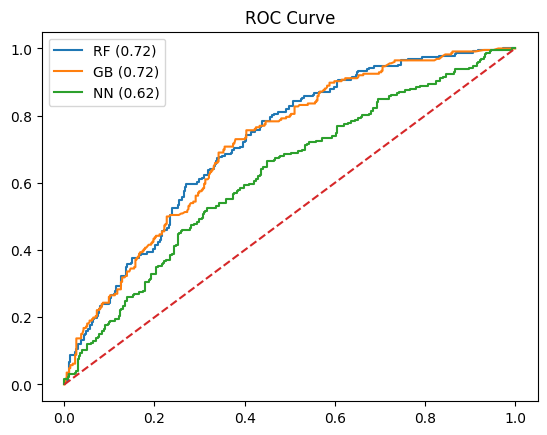

In [ ]:
plt.plot(fpr_rf, tpr_rf, label="RF (%.2f)"%auc_rf)
plt.plot(fpr_gb, tpr_gb, label="GB (%.2f)"%auc_gb)
plt.plot(fpr_nn, tpr_nn, label="NN (%.2f)"%auc_nn)

plt.plot([0,1],[0,1],'--')

plt.legend()
plt.title("ROC Curve")
plt.show()

Pada grafik ROC Curve, terlihat bahwa model Random Forest dan Gradient Boosting memiliki performa yang hampir sama dan paling baik, dengan nilai AUC sekitar 0,72, sedangkan Neural Network memiliki performa yang lebih rendah dengan AUC sekitar 0,62. Hal ini menunjukkan bahwa Random Forest dan Gradient Boosting lebih mampu dalam membedakan pasien yang akan dirawat ulang dan yang tidak dibandingkan Neural Network.

# Melihat Faktor yang Paling Berpengaruh dalam Prediksi

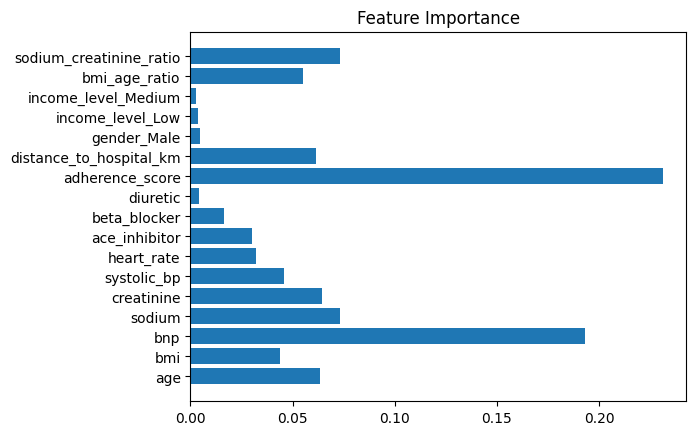

In [ ]:
import matplotlib.pyplot as plt

plt.barh(X.columns, rf_best.feature_importances_)
plt.title("Feature Importance")
plt.show()

Grafik feature importance menunjukkan bahwa variabel yang paling berpengaruh dalam memprediksi readmisi pasien adalah adherence_score (tingkat kepatuhan pasien), diikuti oleh bnp, sodium_creatinine_ratio, dan age. Hal ini mengindikasikan bahwa faktor kondisi medis dan kepatuhan pasien memiliki peran yang jauh lebih besar dibandingkan faktor lain seperti jenis kelamin, tingkat pendapatan, atau penggunaan obat tertentu yang terlihat memiliki pengaruh relatif kecil.

# Membandingkan Akurasi dan Kualitas Model

In [ ]:
from sklearn.metrics import accuracy_score

# hitung akurasi
acc_rf = accuracy_score(y_test, rf_best.predict(X_test))
acc_gb = accuracy_score(y_test, gb_best.predict(X_test))
acc_nn = accuracy_score(y_test, nn_best.predict(X_test))
acc_ens = accuracy_score(y_test, ens_pred)

print("=== AKURASI MODEL ===")
print("Random Forest :", acc_rf)
print("Gradient Boosting :", acc_gb)
print("Neural Network :", acc_nn)
print("Ensemble :", acc_ens)

print("\n=== AUC MODEL ===")
print("Random Forest :", auc_rf)
print("Gradient Boosting :", auc_gb)
print("Neural Network :", auc_nn)

=== AKURASI MODEL ===
Random Forest : 0.66
Gradient Boosting : 0.665
Neural Network : 0.6216666666666667
Ensemble : 0.65

=== AUC MODEL ===
Random Forest : 0.7190383796318206
Gradient Boosting : 0.7154595144574323
Neural Network : 0.6237754957171928


Dari hasil yang diperoleh, terlihat bahwa Gradient Boosting memiliki akurasi tertinggi sebesar sekitar 66,5%, meskipun selisihnya sangat tipis dengan Random Forest (66%) dan Ensemble (65%). Sementara itu, Neural Network memiliki akurasi paling rendah, yaitu sekitar 62%.

Namun jika dilihat dari nilai AUC, justru Random Forest menjadi yang terbaik dengan nilai sekitar 0,72, sedikit lebih unggul dibanding Gradient Boosting (0,71). Ini menunjukkan bahwa Random Forest lebih baik dalam membedakan antara pasien yang dirawat ulang dan yang tidak, meskipun akurasinya sedikit di bawah Gradient Boosting. Neural Network kembali menjadi yang terendah dengan AUC sekitar 0,62.

Secara keseluruhan, Random Forest dan Gradient Boosting adalah dua model terbaik, dengan keunggulan masing-masing. Gradient Boosting unggul di akurasi, sedangkan Random Forest lebih baik dalam kemampuan klasifikasi secara keseluruhan.

# Menentukan Model Terbaik Berdasarkan Nilai AUC

In [ ]:
model_names = ['Random Forest', 'Gradient Boosting', 'Neural Network']
auc_scores = [auc_rf, auc_gb, auc_nn]

best_model = model_names[auc_scores.index(max(auc_scores))]
best_score = max(auc_scores)

print("\n=== MODEL TERBAIK BERDASARKAN AUC ===")
print("Model terbaik adalah:", best_model)
print("Dengan nilai AUC:", best_score)


=== MODEL TERBAIK BERDASARKAN AUC ===
Model terbaik adalah: Random Forest
Dengan nilai AUC: 0.7190383796318206


Berdasarkan hasil evaluasi menggunakan nilai AUC, model terbaik yang diperoleh adalah Random Forest dengan nilai sekitar 0,719. Ini menunjukkan bahwa model tersebut memiliki kemampuan paling baik dalam membedakan pasien yang akan dirawat ulang dan yang tidak dibandingkan model lainnya.

Meskipun selisihnya tidak terlalu jauh dengan Gradient Boosting, Random Forest tetap unggul secara keseluruhan dalam hal kualitas klasifikasi. Oleh karena itu, model ini dapat dipilih sebagai model utama untuk digunakan dalam analisis atau prediksi risiko readmisi pasien.

In [ ]:
print("\n=== KESIMPULAN ===")

print(f"""
Berdasarkan hasil analisis klasifikasi:

1. Model Random Forest memiliki akurasi sebesar {acc_rf:.2f} dan AUC sebesar {auc_rf:.2f}.
2. Model Gradient Boosting memiliki akurasi sebesar {acc_gb:.2f} dan AUC sebesar {auc_gb:.2f}.
3. Model Neural Network memiliki akurasi sebesar {acc_nn:.2f} dan AUC sebesar {auc_nn:.2f}.
4. Model Ensemble memiliki akurasi sebesar {acc_ens:.2f}.

Model terbaik adalah {best_model} karena memiliki nilai AUC tertinggi yaitu {best_score:.2f},
yang menunjukkan kemampuan terbaik dalam membedakan kelas readmission.

Secara keseluruhan, metode boosting dan ensemble memberikan performa yang lebih baik
dibandingkan metode lainnya dalam kasus ini.
""")


=== KESIMPULAN ===

Berdasarkan hasil analisis klasifikasi:

1. Model Random Forest memiliki akurasi sebesar 0.66 dan AUC sebesar 0.72.
2. Model Gradient Boosting memiliki akurasi sebesar 0.67 dan AUC sebesar 0.72.
3. Model Neural Network memiliki akurasi sebesar 0.62 dan AUC sebesar 0.62.
4. Model Ensemble memiliki akurasi sebesar 0.65.

Model terbaik adalah Random Forest karena memiliki nilai AUC tertinggi yaitu 0.72,
yang menunjukkan kemampuan terbaik dalam membedakan kelas readmission.

Secara keseluruhan, metode boosting dan ensemble memberikan performa yang lebih baik
dibandingkan metode lainnya dalam kasus ini.

